## Environment Setup and Required Libraries

Import the libraries required for data manipulation, visualization, preprocessing, hyperparameter optimization, KNN regression, model evaluation, and model persistence.


In [26]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Loading the Prepared Training and Testing Data

Load the predefined training and testing features and target values generated during the preprocessing stage, ensuring that the same data split is used for model development and evaluation.


In [27]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (13463, 6)
Testing features : (3366, 6)
Training target  : (13463,)
Testing target   : (3366,)


## Numerical and Categorical Feature Definition

Define the numerical and categorical features separately so that each group can receive the appropriate preprocessing transformation.


In [28]:
numerical_features = [
    "Latitude",
    "Longitude",
    "Signal Strength (dBm)",
    "Latency (ms)"
]

categorical_features = [
    "Locality",
    "Network Type"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Latitude', 'Longitude', 'Signal Strength (dBm)', 'Latency (ms)']

Categorical features:
['Locality', 'Network Type']


## Feature Preprocessing Configuration

Configure a preprocessing pipeline that standardizes numerical features and converts categorical features into numerical representations using one-hot encoding.


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

## KNN Regression Pipeline

Construct an end-to-end KNN Regression pipeline that combines feature preprocessing with the K-Nearest Neighbors regression model.


In [30]:
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor())
    ]
)

print("KNN regression pipeline created successfully.")

KNN regression pipeline created successfully.


## KNN Hyperparameter Search Space

Define the hyperparameters to be optimized, including the number of neighbors and the weighting strategy used by the KNN regressor.


In [31]:
param_grid = {
    "model__n_neighbors": range(1, 31),
    "model__weights": [
        "uniform",
        "distance"
    ]
}

print("Hyperparameter search space:")
print(param_grid)

Hyperparameter search space:
{'model__n_neighbors': range(1, 31), 'model__weights': ['uniform', 'distance']}


## KNN Hyperparameter Optimization with Cross-Validation

Use GridSearchCV with five-fold cross-validation to evaluate different KNN configurations and select the configuration that minimizes Mean Absolute Error.


In [19]:
grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter optimization completed successfully.")

Hyperparameter optimization completed successfully.


## Optimal KNN Configuration

Inspect the best hyperparameter combination identified during cross-validation along with its corresponding cross-validation Mean Absolute Error.


In [20]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(-grid_search.best_score_)

Best parameters:
{'model__n_neighbors': 27, 'model__weights': 'distance'}

Best Cross-Validation MAE:
6.511542888139099


## Retrieving the Optimized KNN Pipeline

Retrieve the best-performing KNN pipeline identified by the hyperparameter search for final training-set and test-set evaluation.


In [21]:
knn_pipeline = grid_search.best_estimator_

print("Optimized KNN pipeline is ready.")

Optimized KNN pipeline is ready.


## Generating KNN Predictions

Generate throughput predictions for both the training and testing datasets using the optimized KNN pipeline.


In [22]:
y_pred_train = knn_pipeline.predict(X_train)
y_pred_test = knn_pipeline.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


## KNN Regression Performance Evaluation

Evaluate the optimized KNN model using MAE, MSE, RMSE, and R² on both training and testing datasets to assess prediction accuracy and generalization performance.


In [23]:
train_mae = mean_absolute_error(y_train, y_pred_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

print("Training Performance")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\nTest Performance")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

Training Performance
MAE  : 0.0000
MSE  : 0.0000
RMSE : 0.0000
R²   : 1.0000

Test Performance
MAE  : 6.6088
MSE  : 180.1659
RMSE : 13.4226
R²   : 0.7322


## Actual vs Predicted Throughput

Visualize the relationship between actual and predicted throughput values on the test set. The reference diagonal represents perfect predictions, allowing deviations from ideal predictions to be visually assessed.


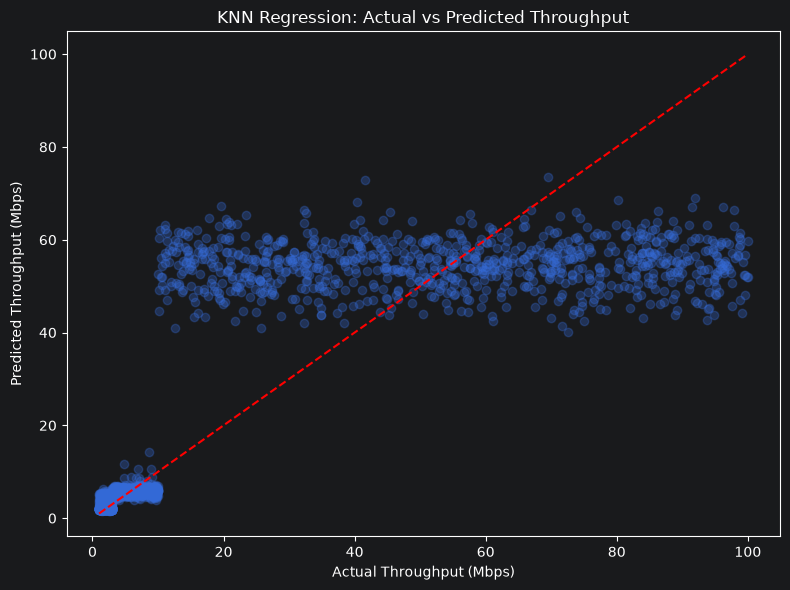

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Throughput (Mbps)")
plt.ylabel("Predicted Throughput (Mbps)")
plt.title("KNN Regression: Actual vs Predicted Throughput")

plt.tight_layout()
plt.show()

## Saving the Optimized KNN Pipeline

Persist the optimized KNN pipeline, including its preprocessing steps and selected hyperparameters, as a Joblib file for reuse in the Streamlit application and future inference.


In [25]:
model_path = "../models/knn.joblib"

joblib.dump(
    knn_pipeline,
    model_path
)

print(f"KNN pipeline saved successfully to: {model_path}")

KNN pipeline saved successfully to: ../models/knn.joblib
